In [6]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb
from scipy.stats import randint, uniform

In [2]:
# 1. Read the newly saved CSV file
df = pd.read_csv('data/cleaned_loan_data_revised_v4.csv')

# 2. Extract the column names into a native Python list
clean_columns = df.columns.tolist()

# 3. Print the total count and the list of columns
print(f"Total columns loaded: {len(clean_columns)}\n")
print("--- Cleaned Dataset Columns ---")
for col in clean_columns:
    print(col)

Total columns loaded: 16

--- Cleaned Dataset Columns ---
NAME_INCOME_TYPE
NAME_EDUCATION_TYPE
NAME_FAMILY_STATUS
CNT_CHILDREN
FLAG_OWN_CAR
FLAG_OWN_REALTY
NAME_HOUSING_TYPE
TARGET
AGE_YEARS
YEARS_EMPLOYED
FLAG_EMP_ANOMALY
CREDIT_INCOME_RATIO
ADULT_IN_HOUSE
EST_LOAN_TERM
ANNUITY_MONTHLY_INCOME_RATIO
CHILDREN_TO_FAMILY_RATIO


In [3]:
# Moved the two FLAG columns here
categorical_cols = [
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 
    'NAME_HOUSING_TYPE', 'NAME_FAMILY_STATUS',
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_EMP_ANOMALY'
]

# Removed the two FLAG columns and the duplicate HOUSING column
numerical_cols = [
    'CNT_CHILDREN', 'AGE_YEARS', 
    'YEARS_EMPLOYED', 'ADULT_IN_HOUSE', 'EST_LOAN_TERM',
    "ANNUITY_MONTHLY_INCOME_RATIO", "CHILDREN_TO_FAMILY_RATIO",'CREDIT_INCOME_RATIO'
]

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        # Apply standard scaling to numerical features
        ('num', StandardScaler(), numerical_cols),
        
        # Apply One-Hot Encoding to categorical features
        # handle_unknown='ignore' prevents crashes if a weird category pops up in the future
        # drop='first' helps prevent multicollinearity by dropping one binary column per category
        ('cat', OneHotEncoder(handle_unknown='ignore', drop=None), categorical_cols)
    ])

In [5]:
X = df[categorical_cols + numerical_cols]
y = df['TARGET']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated scale_pos_weight: {imbalance_ratio:.2f}")

# 1. Initialize the pipeline with the optimized hyperparameters
final_xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', xgb.XGBClassifier(
        colsample_bytree=np.float64(0.8816959312936001),
        gamma=np.float64(0.3897543375882201),
        learning_rate=np.float64(0.03484952653770334),
        max_depth=4,
        min_child_weight=7,
        n_estimators=538,
        subsample=np.float64(0.760589108555312),
        reg_alpha=np.float64(4.957772012481057),
        reg_lambda=np.float64(0.8366009452689833),
        scale_pos_weight=imbalance_ratio,
        objective='binary:logistic',      
        eval_metric='auc',                
        random_state=42,
        n_jobs=-1
    ))
])

# Convert Pandas Series to pure NumPy arrays to bypass the version bug
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

# 2. Train the model on the NumPy array
final_xgb_pipeline.fit(X_train, y_train_np)

# 3. Generate probabilities and predictions
y_prob_xgb = final_xgb_pipeline.predict_proba(X_test)[:, 1]
y_pred_xgb = final_xgb_pipeline.predict(X_test)

# 4. Evaluate using the NumPy version of y_test
print("\n--- Final Optimized XGBoost Evaluation ---")
print(f"Test Set ROC-AUC Score: {roc_auc_score(y_test_np, y_prob_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_np, y_pred_xgb))

Calculated scale_pos_weight: 11.34

--- Final Optimized XGBoost Evaluation ---
Test Set ROC-AUC Score: 0.6722

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.65      0.77     39562
           1       0.13      0.61      0.22      3490

    accuracy                           0.65     43052
   macro avg       0.54      0.63      0.50     43052
weighted avg       0.88      0.65      0.73     43052



In [8]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize JavaScript for the interactive Force Plot
shap.initjs()

# 2. Extract the preprocessor and the model from your pipeline
preprocessor = final_xgb_pipeline.named_steps['preprocessor']
xgb_model = final_xgb_pipeline.named_steps['classifier']

# 3. Subset the first 200 rows and transform them
# (Handling both pandas and numpy formats safely)
if isinstance(X_test, pd.DataFrame):
    X_test_200 = X_test.iloc[:200]
else:
    X_test_200 = X_test[:200]

X_test_200_transformed = preprocessor.transform(X_test_200)

# If your preprocessor outputs a sparse matrix (common with OneHotEncoder), make it dense
if hasattr(X_test_200_transformed, 'toarray'):
    X_test_200_transformed = X_test_200_transformed.toarray()

# 4. Attach feature names so the plots are readable
try:
    feature_names = preprocessor.get_feature_names_out()
    X_200_df = pd.DataFrame(X_test_200_transformed, columns=feature_names)
except AttributeError:
    # Fallback if your preprocessor doesn't support get_feature_names_out
    print("Warning: Could not retrieve feature names. Using numbers.")
    X_200_df = pd.DataFrame(X_test_200_transformed)

# 5. Generate predictions to find our target instances
preds_200 = xgb_model.predict(X_200_df)
idx_1 = np.where(preds_200 == 1)[0] # Predicted Default
idx_0 = np.where(preds_200 == 0)[0] # Predicted No Default

# Select 3 defaults and 2 non-defaults (or as many as available)
selected_idx = np.concatenate([idx_1[:3], idx_0[:2]])



C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== INDIVIDUAL PROBABILITY WATERFALL PLOTS ===

Row Index: 0 | Model Prediction: 1 | Model Probability: 0.5209


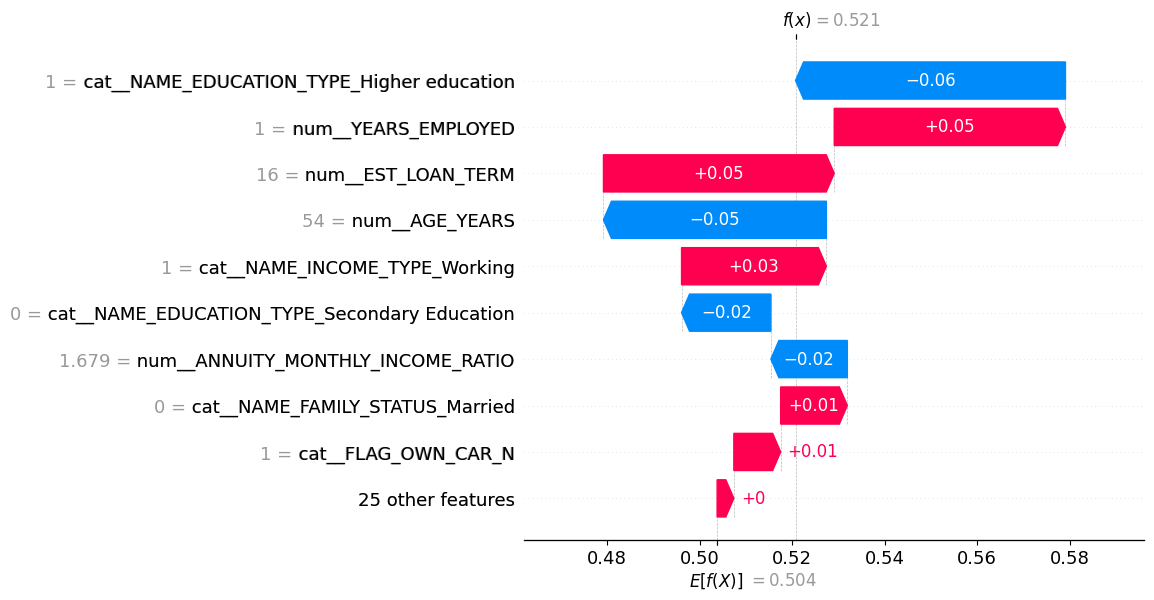


Row Index: 9 | Model Prediction: 1 | Model Probability: 0.5760


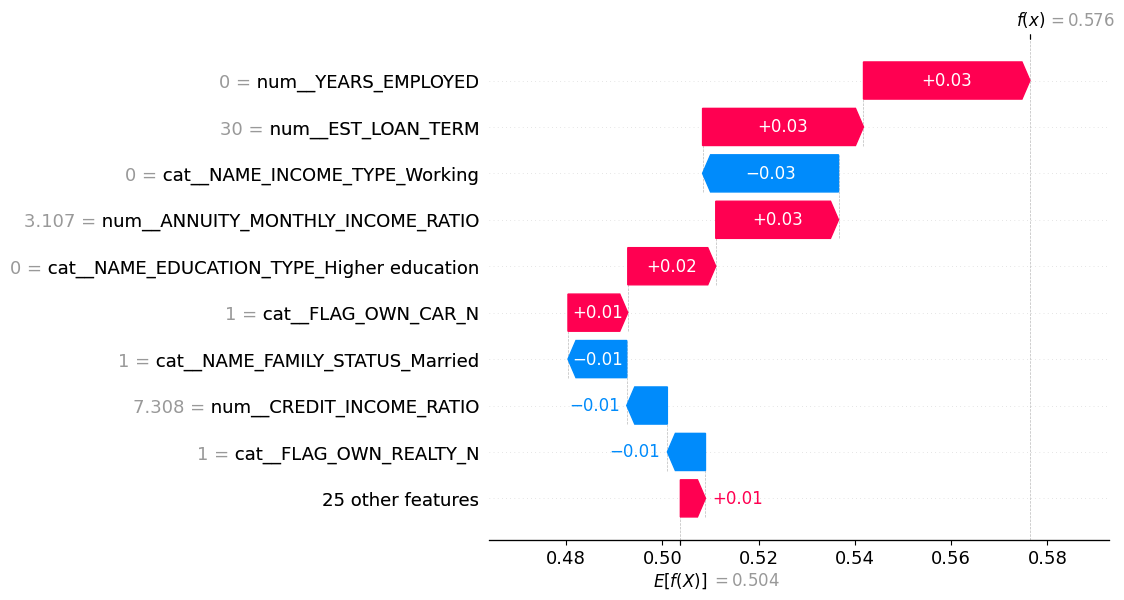


Row Index: 10 | Model Prediction: 1 | Model Probability: 0.6537


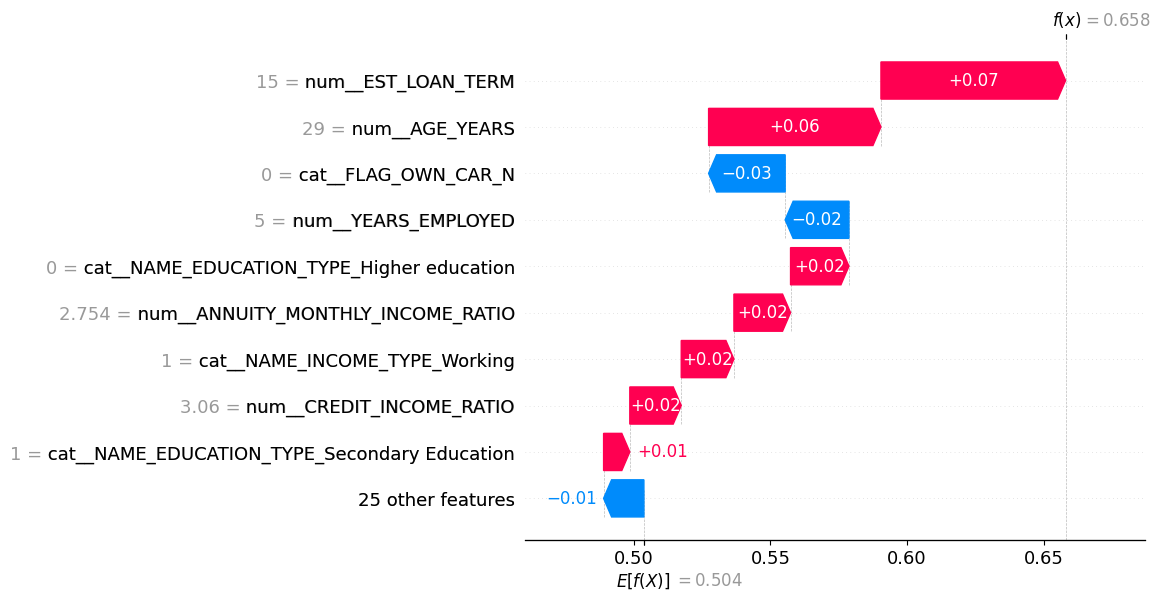


Row Index: 1 | Model Prediction: 0 | Model Probability: 0.3675


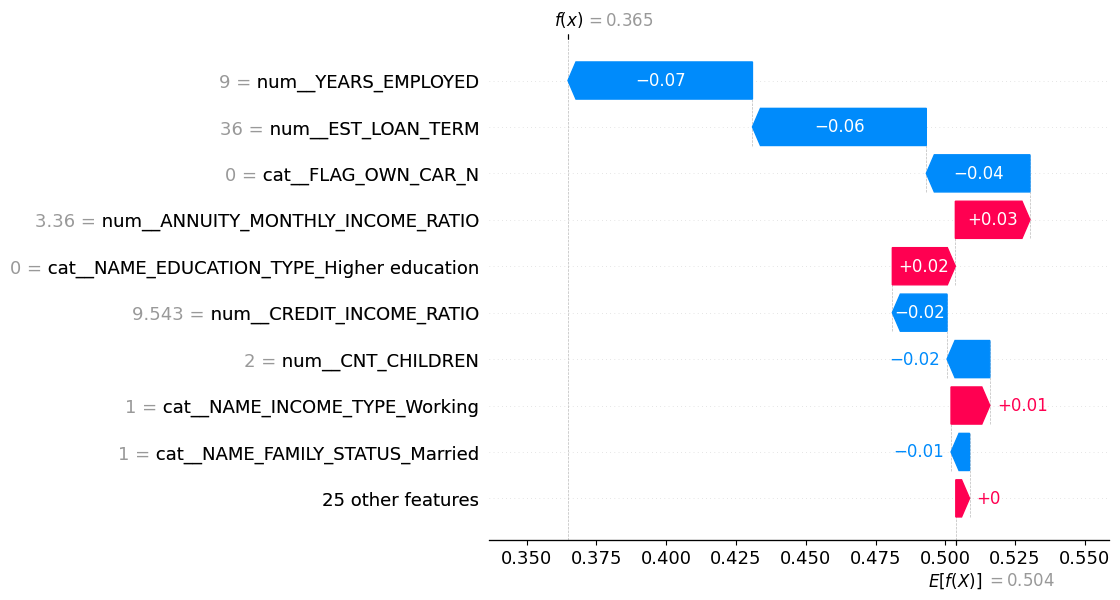


Row Index: 2 | Model Prediction: 0 | Model Probability: 0.3035


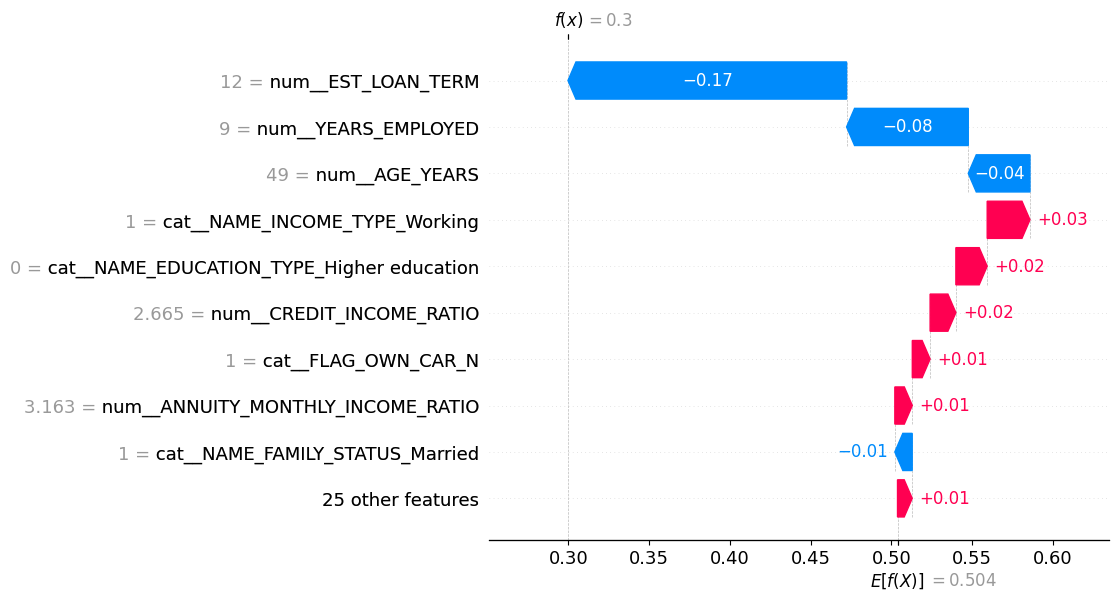


=== COLLECTIVE PROBABILITY BEESWARM PLOT ===


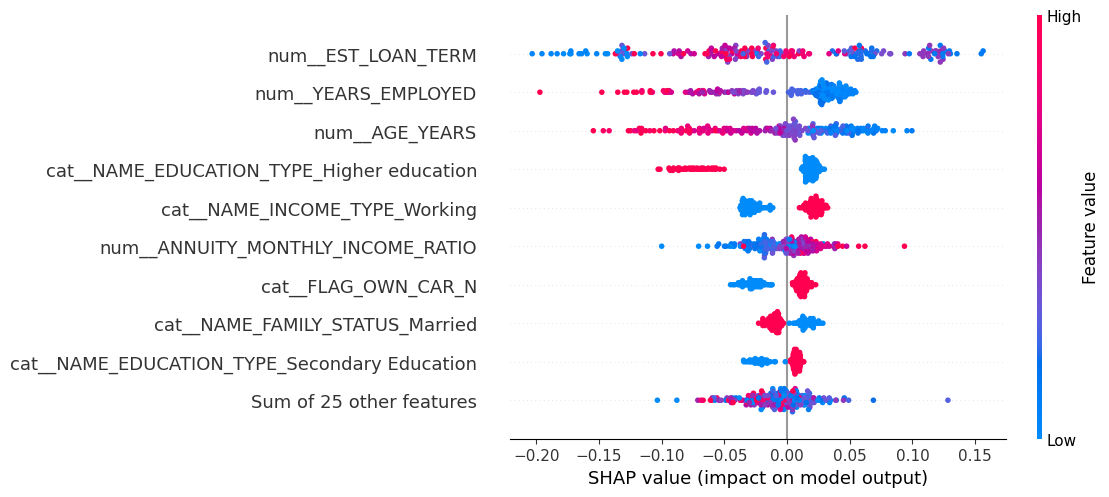


=== COLLECTIVE PROBABILITY DEPENDENCE PLOT ===
Showing dependence plot for main feature: num__CNT_CHILDREN


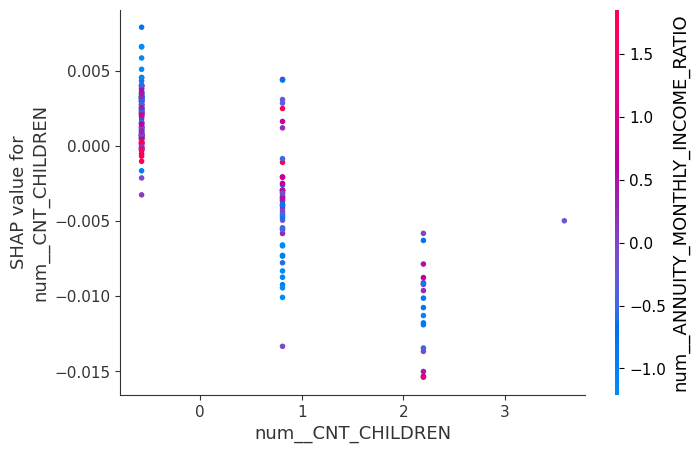


=== COLLECTIVE INTERACTIVE PROBABILITY FORCE PLOT ===


In [9]:
# ==========================================
# 6. Calculate SHAP values (FORCING PROBABILITIES & ACTUAL VALUES)
# ==========================================
explainer = shap.TreeExplainer(xgb_model)
shap_values_raw = explainer(X_200_df)

# Define a Sigmoid (Logistic) function to convert raw log-odds output
sigmoid = lambda x: 1 / (1 + np.exp(-x))

# Calculate the probability-scale geometries for the bars
expected_value_prob = sigmoid(explainer.expected_value)
shap_values_prob_matrix = sigmoid(explainer.expected_value + shap_values_raw.values) - expected_value_prob

# --- NEW STEP: Create a display dataframe with unscaled values ---
X_200_display = X_200_df.copy()

for col in X_200_display.columns:
    # Look for the numerical columns that were scaled
    if col.startswith("num__"):
        # Strip the 'num__' prefix to match your original raw column name
        original_col_name = col.replace("num__", "")
        
        # Pull the real, unscaled data from your original X_test_200 
        if original_col_name in X_test_200.columns:
            X_200_display[col] = X_test_200[original_col_name].values

# --- Reconstruct the SHAP Explanation object ---
# Notice we pass 'data=X_200_display' instead of X_200_df
shap_values_prob = shap.Explanation(
    values=shap_values_prob_matrix,
    base_values=expected_value_prob,
    data=X_200_display,  # <--- SHAP will now read text labels from here!
    feature_names=feature_names
)

# --- (Loop structures from original code preserved, but using shap_values_prob) ---
print("=== INDIVIDUAL PROBABILITY WATERFALL PLOTS ===")
for i, idx in enumerate(selected_idx):
    actual_pred = preds_200[idx]
    
    # Optional: Calculate the specific predicted probability for printing
    actual_prob = sigmoid(explainer.expected_value + shap_values_raw.values[idx].sum())
    
    print(f"\nRow Index: {idx} | Model Prediction: {actual_pred} | Model Probability: {actual_prob:.4f}")
    
    # Create the probability-scale waterfall plot
    # The X-axis is now clearly a 0.0 to 1.0 probability scale.
    shap.plots.waterfall(shap_values_prob[idx])
    plt.show() # Forces Jupyter to render the plot before moving to the next loop

print("\n=== COLLECTIVE PROBABILITY BEESWARM PLOT ===")
# The beeswarm plot now ranks features by their average probability-scale impact.
# The scale is now a change in probability from the base value.
shap.plots.beeswarm(shap_values_prob)
plt.show()

print("\n=== COLLECTIVE PROBABILITY DEPENDENCE PLOT ===")
# Note: Interaction effects on probabilities are complex; we plot the main effect on probability.
# Plotting probability impact against raw feature value.
top_feature = X_200_df.columns[0]
print(f"Showing dependence plot for main feature: {top_feature}")
shap.dependence_plot(0, shap_values_prob.values, X_200_df)
plt.show()

print("\n=== COLLECTIVE INTERACTIVE PROBABILITY FORCE PLOT ===")
# Base value and final output are now visible as probabilities (0.0 to 1.0 scale).
# MUST be the last thing in the cell to render correctly in Jupyter.
shap.force_plot(expected_value_prob, shap_values_prob.values, X_200_df)

In [10]:
import joblib

# Choose a name for your file (it will save in the same folder as your notebook)
file_name = "loan_default_xgb_pipeline_v3.joblib"

# Save the entire pipeline (preprocessor + xgb_model)
joblib.dump(final_xgb_pipeline, file_name)

print(f"Model successfully saved as: {file_name}")

Model successfully saved as: loan_default_xgb_pipeline_v3.joblib
